### Load and visualize the _AVMNIST_ dataset

In [1]:
import sys
import os
sys.path.append(os.getcwd())
# append the root directory to the sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from PIL import Image
import random
import matplotlib.pyplot as plt

### Load train - validation - test data

In [3]:
data_dir = '../data/multibench/avmnist'  # Path to the AVMNIST data directory
from src.preprocessing.avmnist_get_data import get_dataloader

train_data, valid_data, test_data = get_dataloader(data_dir = data_dir)

### Visualize input sample

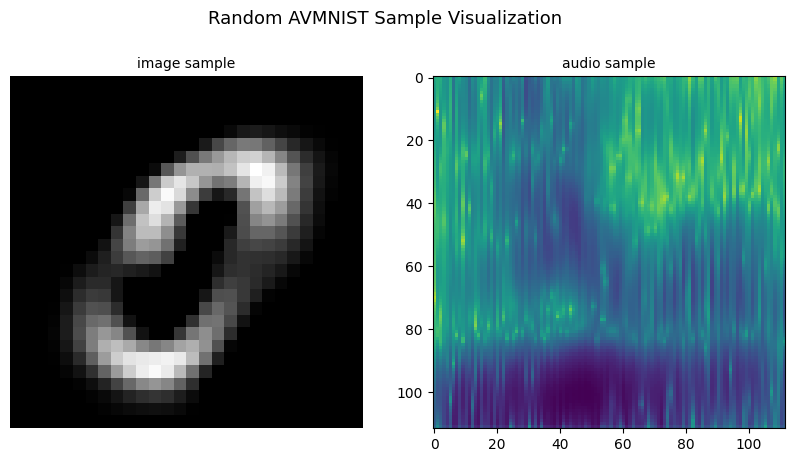

In [4]:
# visualize random input sample (image, audio) 

random_idx = random.randint(0, len(train_data.dataset)-1)

rdm_image = train_data.dataset[random_idx][0]
rdm_audio = train_data.dataset[random_idx][1]


img = Image.new('L', (28, 28))
# both the image and the audio data (represented as spectogram) are multiplied by 255 for visualization
# as they are normalized to [0,1] during preprocessing
img.putdata(rdm_image.squeeze().reshape(-1,) * 255)
audio_spec = Image.new('L', (112, 112))
audio_spec.putdata(rdm_audio.squeeze().reshape(-1,) * 255)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle('Random AVMNIST Sample Visualization', fontsize= 13)

ax[0].imshow(img, cmap='gray')
ax[0].set_title('image sample', fontsize= 10)
ax[0].axis('off')
ax[1].imshow(audio_spec)
ax[1].set_title('audio sample', fontsize= 10)
plt.show()